In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import ifft, fft, fftfreq, fftshift, ifft2, fft2
from scipy.io import wavfile
from scipy.signal import hilbert
from audio_function import *

In [28]:
fs, data_micr_calibr =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/ PGD_2702/TASCAM_0372S1.wav')

fs, data_micr_noise_big =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/ PGD_2702/TASCAM_0371S1.wav')
fs, data_pgd_noise_big =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/ PGD_2702/TASCAM_0371S2.wav')
data_pgd_noise_big = data_pgd_noise_big / 10 # коэф усиления перед ПГД
fs, data_pgd_calibr =  wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/ PGD_2702/TASCAM_0373S2.wav')

rho = 1.2255
c = 340

In [29]:
import numpy as np

def generate_octave_bands(octave_fraction=12, f_low=80, f_high=10000, f_ref=1000):
    """
    Генерация октавных полос аналогично MATLAB коду
    
    Parameters:
    octave_fraction : int - дробность октавы (3, 6, 12, 24, 48)
    f_low : float - нижняя частота диапазона (Гц)
    f_high : float - верхняя частота диапазона (Гц) 
    f_ref : float - опорная частота (Гц)
    """
    # Вычисляем индексы как в MATLAB
    start_idx = np.round(np.log2(f_low/f_ref) * octave_fraction) + 1
    end_idx = np.round(np.log2(f_high/f_ref) * octave_fraction) - 1
    
    # Создаем диапазон индексов
    indices = np.arange(start_idx, end_idx + 1)  # +1 т.к. в Python конец не включается
    
    # Центральные частоты
    f0 = f_ref * 2.**(indices / octave_fraction)
    
    # Граничные частоты
    bandwidth_factor = 2**(1/(2*octave_fraction))
    f_down = f0 / bandwidth_factor
    f_up = f0 * bandwidth_factor
    
    return f0, f_down, f_up

# --- Примеры использования (аналогично MATLAB коду) ---

print("=== 1/12 октавы (как в активном коде) ===")
f0, f_down, f_up = generate_octave_bands(octave_fraction=12, f_low=80, f_high=10000)
# print(f"Центральные частоты: {f0}")
# print(f"Нижние границы: {f_down}")
# print(f"Верхние границы: {f_up}")


=== 1/12 октавы (как в активном коде) ===


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


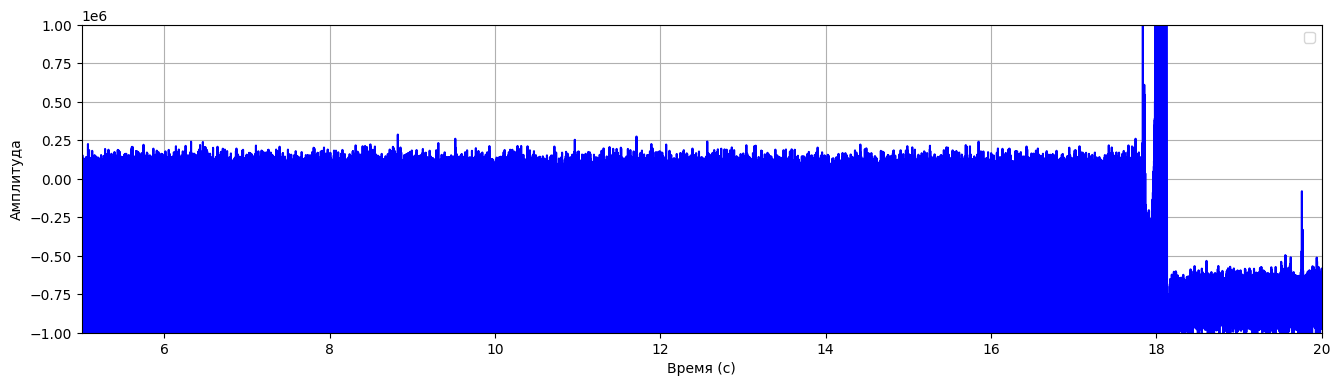

In [30]:
t_micr_calibr = np.arange(len(data_micr_calibr))/fs
f_micr_calibr = fftfreq(len(data_micr_calibr), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(t_micr_calibr, data_micr_calibr, color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.xlim(5, 20)
plt.ylim(-1e6, 1e6)
plt.grid(True)
plt.show()

In [31]:
# Выделям временной участок, на котором калибровка чистая
t_index = (t_micr_calibr > 10) & (t_micr_calibr < 15)
t_1000Hz = t_micr_calibr[t_index]

data_micr_calibr_5sec = data_micr_calibr[t_index]
data_micr_calibr_5sec = data_micr_calibr_5sec - np.mean(data_micr_calibr_5sec)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


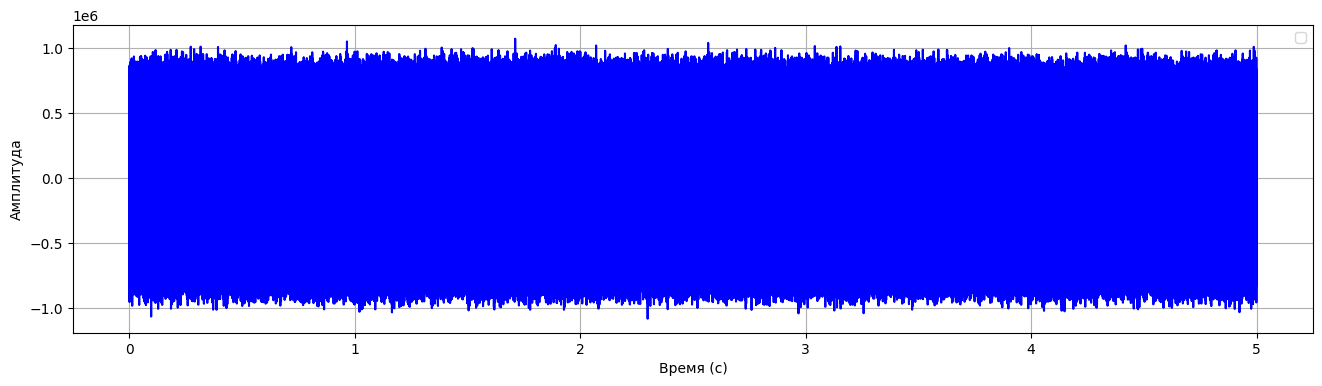

In [32]:
 signal = data_micr_calibr_5sec 
 t = np.arange(len(signal))/fs
 f = fftfreq(len(signal), 1 / fs)
 plt.figure(figsize=(16,4))
 plt.plot(t,(((signal))), color='blue')
 plt.legend()
 plt.xlabel("Время (с)")
 plt.ylabel("Амплитуда")
 plt.grid(True)
 # plt.xlim(0, 10500)
# # plt.ylim(-5, 1e11)
 plt.show()

In [33]:
# Находим коэффициент усиления шумомера и учитываем его
data_micr_calibr_5sec = ifft(filt_freq(fft(data_micr_calibr_5sec), 990, 1010, fs))
impl_dB = 20
# k_impl = 10**(impl_dB/20)
k_impl = 1
data_micr_calibr_5sec = data_micr_calibr_5sec / k_impl

# Находим коэффициента пересчета из отн. ед. в 
k_t = RMS(data_micr_calibr_5sec)
k_to_pa = 1 / k_t
k_to_pa

1.7359272226510838e-06

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


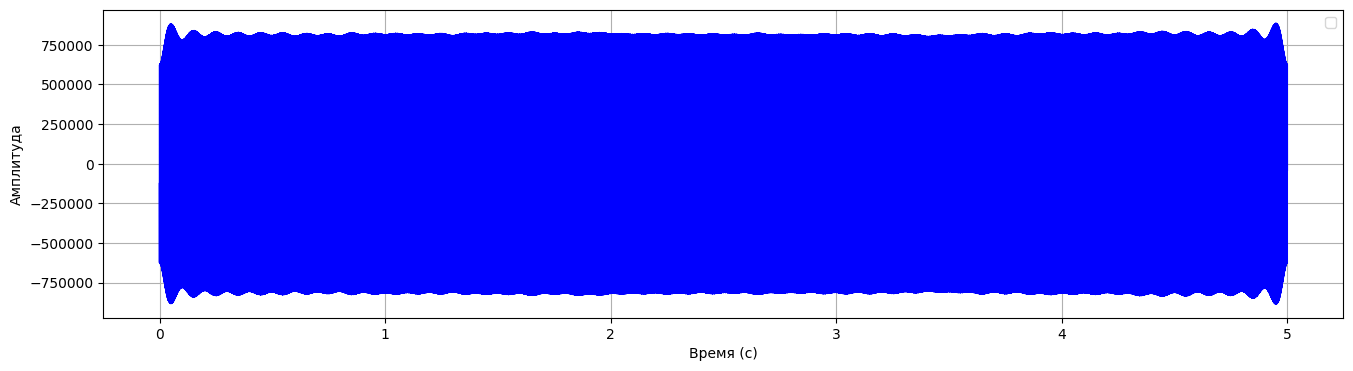

In [34]:
 signal = data_micr_calibr_5sec 
 t = np.arange(len(signal))/fs
 f = fftfreq(len(signal), 1 / fs)
 plt.figure(figsize=(16,4))
 plt.plot(t,(((signal))), color='blue')
 plt.legend()
 plt.xlabel("Время (с)")
 plt.ylabel("Амплитуда")
 plt.grid(True)
 # plt.xlim(0, 10500)
# # plt.ylim(-5, 1e11)
 plt.show()

In [35]:
# signal = data_micr_noise_big
# t = np.arange(len(signal))/fs
# f = fftfreq(len(signal), 1 / fs)
# plt.figure(figsize=(16,4))
# plt.plot(f, np.abs((fft(signal))), color='blue')
# plt.legend()
# plt.xlabel("Время (с)")
# plt.ylabel("Амплитуда")
# plt.grid(True)
# plt.xlim(700, 3000)
# plt.ylim(0, 1e11)
# plt.show()

In [36]:
data_micr_calibr_pa = data_micr_calibr * k_to_pa
data_micr_calibr_5sec_pa = data_micr_calibr_5sec * k_to_pa
data_micr_noise_big_pa = data_micr_noise_big * k_to_pa

In [37]:
RMS(data_micr_noise_big_pa)

1.3956712687247663

In [38]:
# signal = data_micr_noise_big
# t = np.arange(len(signal))/fs
# f = fftfreq(len(signal), 1 / fs)
# plt.figure(figsize=(16,4))
# plt.plot(t, (((signal))), color='blue')
# plt.legend()
# plt.xlabel("Время (с)")
# plt.ylabel("Амплитуда, Па")
# plt.grid(True)
# # plt.xlim(0, 500)
# # plt.ylim(0, 0.002)
# plt.show()

In [39]:
# signal = data_pgd_calibr - np.mean(data_pgd_calibr)
# t = np.arange(len(signal))/fs
# f = fftfreq(len(signal), 1 / fs)
# plt.figure(figsize=(16,4))
# plt.plot(f, np.abs(fft(signal))/len(signal), color='blue')
# plt.legend()
# plt.xlabel("f, Гц")
# plt.ylabel("Амплитуда, Па")
# plt.grid(True)
# # plt.xlim(0, 250)
# # plt.ylim(0, 0.00008)
# plt.show()

In [40]:
# signal = data_pgd_calibr - np.mean(data_pgd_calibr)
# data_micr_noise_big_pa_rms = RMS(data_micr_noise_big_pa)
# dB_level = 20 * np.log10(data_micr_noise_big_pa_rms / 2e-5)
# dB_level

In [41]:
# data_micr_calibr_rms = RMS(data_micr_calibr_pa)
# dB_level = 20 * np.log10(data_micr_calibr_rms / 2e-5)
# dB_level

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


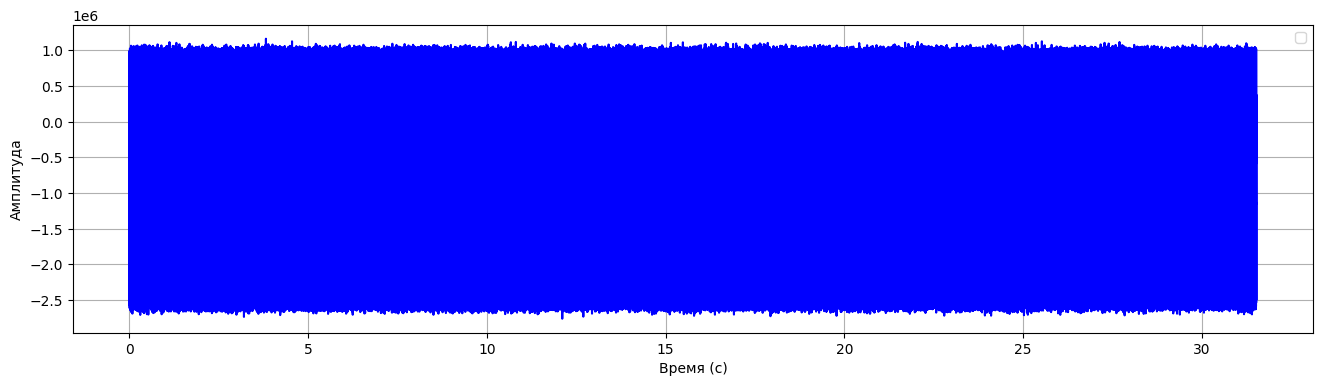

In [42]:
t_pgd_calibr = np.arange(len(data_pgd_calibr))/fs
f_pgd_calibr = fftfreq(len(data_pgd_calibr), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(t_pgd_calibr, data_pgd_calibr, color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

# Выделям временной участок, на котором калибровка


In [43]:
# Выделям временной участок, на котором калибровка
t_begin = 5
t_finish = 10
t_index = (t_pgd_calibr > t_begin) & (t_pgd_calibr < t_finish)
t_1000Hz = t_pgd_calibr[t_index]

data_pgd_calibr_5sec = data_pgd_calibr[t_index]
# data_pgd_calibr_5sec = data_pgd_calibr_5sec - np.mean(data_pgd_calibr_5sec)

# Калибровка сигнала с ПГД для перевода из отн. ед. в мВ


In [44]:
# Калибровка сигнала с ПГД для перевода из отн. ед.
data_pgd_calibr_5sec = ifft(filt_freq(fft(data_pgd_calibr_5sec), 990, 1010, fs))
mv_gen = 224
RMS_gen = RMS(data_pgd_calibr_5sec)
k_to_mv = mv_gen / RMS_gen

data_pgd_noise_big_mv = data_pgd_noise_big * k_to_mv
k_to_mv

0.00018404888807317107

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


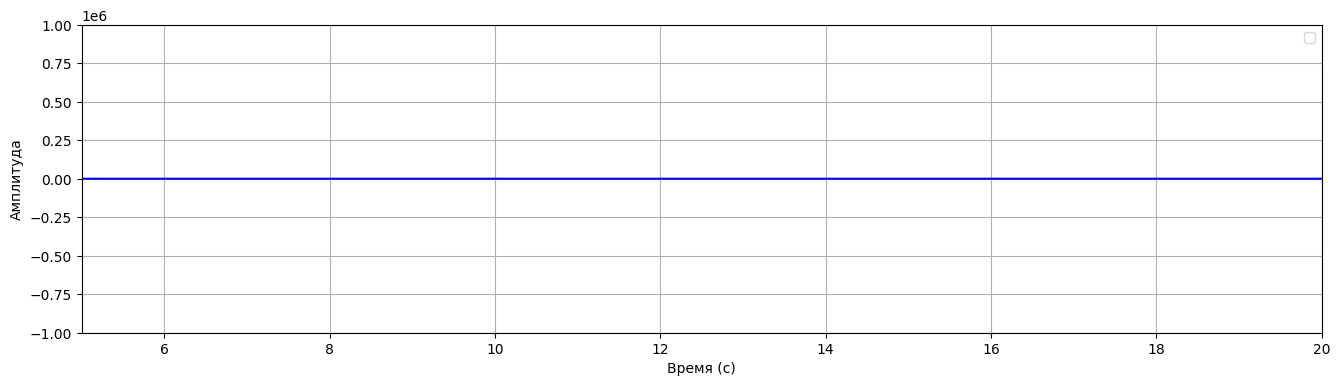

In [45]:
t_pgd_noise = np.arange(len(data_pgd_noise_big_mv))/fs
f_pgd_noise = fftfreq(len(data_pgd_noise_big_mv), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(t_pgd_noise, data_pgd_noise_big_mv, color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.xlim(5, 20)
plt.ylim(-1e6, 1e6)
plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


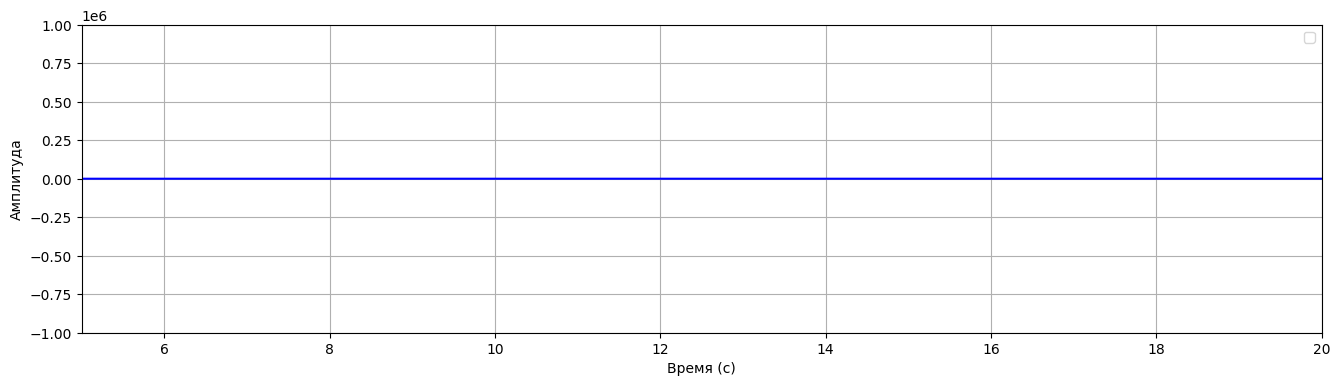

In [46]:
t_micr_noise = np.arange(len(data_micr_noise_big_pa))/fs
f_micr_noise = fftfreq(len(data_micr_noise_big_pa), 1 / fs)
plt.figure(figsize=(16,4))
plt.plot(t_micr_noise, data_micr_noise_big_pa, color='blue')
plt.legend()
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.xlim(5, 20)
plt.ylim(-1e6, 1e6)
plt.grid(True)
plt.show()

In [47]:
t_begin = 70
t_finish = 75
t_index = (t_pgd_noise > t_begin) & (t_pgd_noise < t_finish)
t_noise = t_pgd_noise[t_index]

data_pgd_noise_big_5sec_mv = data_pgd_noise_big_mv[t_index]
data_micr_noise_big_5sec_pa = data_micr_noise_big_pa[t_index]

Задаем 2 массива RMS по октавным фильтрам для рассчета коэффициента чувствительности в мВ/Па


In [48]:

Z0 = rho*c
data_micr_noise_big_vel = data_micr_noise_big_pa / Z0

# data_micr_noise_big_pa = data_micr_noise_big_pa - np.mean(data_micr_noise_big_pa)
# data_pgd_noise_big_mv = data_pgd_noise_big_mv - np.mean(data_pgd_noise_big_mv)

amplitudes_microphone = []
for f1, f2 in zip(f_down, f_up):
    data_1_filt = ifft(filt_freq(fft(data_micr_noise_big_5sec_pa), f1, f2, fs))
    amp = RMS(data_1_filt)
    amplitudes_microphone.append(amp)

amplitudes_PGD = []
for f1, f2 in zip(f_down, f_up):
    data_2_filt = ifft(filt_freq(fft(data_pgd_noise_big_5sec_mv), f1, f2, fs))
    amp = RMS(data_2_filt)
    amplitudes_PGD.append(amp)

amplitudes_microphone = np.array(amplitudes_microphone)
amplitudes_PGD = np.array(amplitudes_PGD)
calibration_coef = amplitudes_PGD / amplitudes_microphone

In [49]:

# Z0 = rho*c


# amplitudes_microphone = []
# for f1, f2 in zip(f_down, f_up):
#     data_1_filt = ifft(filt_freq(fft(data_micr_noise_big), f1, f2, fs))
#     amp = RMS(data_1_filt)
#     amplitudes_microphone.append(amp)

# amplitudes_PGD = []
# for f1, f2 in zip(f_down, f_up):
#     data_2_filt = ifft(filt_freq(fft(data_pgd_noise_big), f1, f2, fs))
#     amp = RMS(data_2_filt)
#     amplitudes_PGD.append(amp)

# amplitudes_microphone = np.array(amplitudes_microphone)
# amplitudes_PGD = np.array(amplitudes_PGD)
# calibration_coef = amplitudes_PGD / amplitudes_microphone

In [50]:
from scipy import interpolate

dB_level_calibr = 20 * np.log10( calibration_coef / calibration_coef[0])

def moving_average(data, window_size):
    """Скользящее среднее"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window = 5
y_smooth_ = moving_average(calibration_coef, window)
y_smooth_db_ = moving_average(dB_level_calibr, window)

# plt.figure(figsize=(16,4))
# plt.plot(f0[window-1:], y_smooth, 'r-', linewidth=2, color='blue')
# plt.legend()
# plt.xlabel("Частота, Гц")
# plt.ylabel("Чувствительность, мВ/Па")
# plt.grid(True)
# plt.title('Чувствительность на подвесе')
# plt.xscale('log')
# plt.xlim(100, 10001)
# plt.show()


In [51]:
#from scipy import interpolate

#dB_level_calibr = 20 * np.log10( calibration_coef / calibration_coef[0])

#def moving_average(data, window_size):
 #   """Скользящее среднее"""
  #  return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

#window = 5
#y_smooth = moving_average(dB_level_calibr, window)

#plt.figure(figsize=(16,4))
#plt.plot(f0[window-1:], y_smooth, 'r-', linewidth=2, color='blue')
#plt.legend()
#plt.xlabel("Частота, Гц")
#plt.ylabel("Чувствительность, дБ")
#plt.grid(True)
#plt.title('Калибровка при наличии пола')
#plt.xscale('log')
#plt.xlim(100, 10001)
#plt.show()


/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_7949/1636841521.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(f0[window-1:], y_smooth_, 'r-', linewidth=2, color='blue', label = 'На подвесе')
/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_7949/1636841521.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(f0[window-1:], y_smooth, 'r-', linewidth=2, color='red', label = 'На подложке')


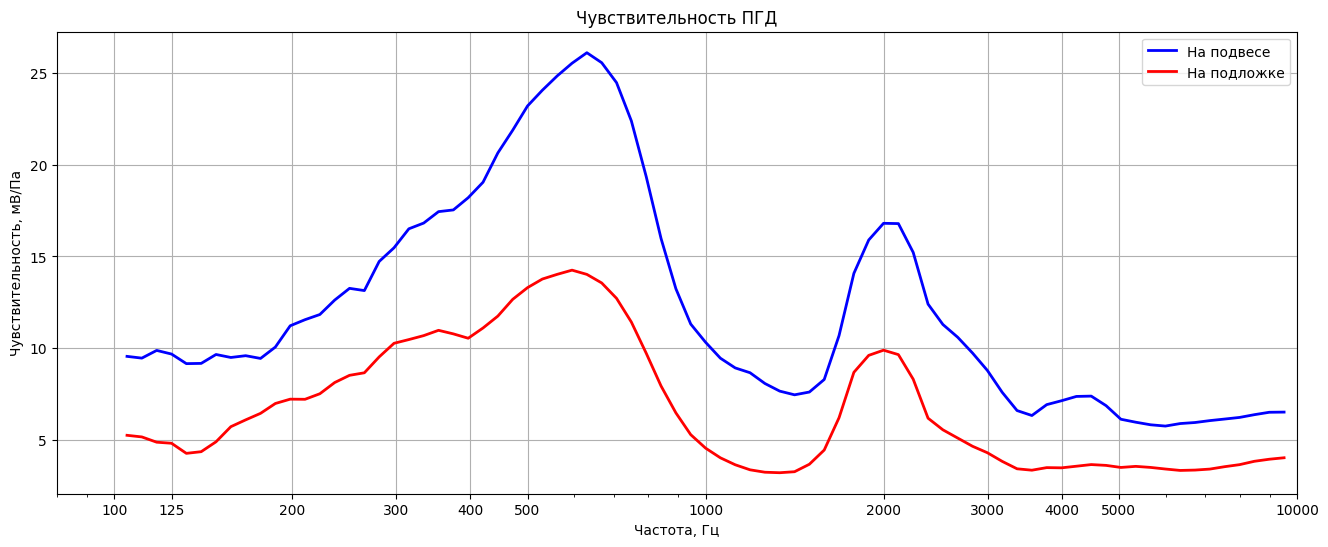

In [52]:
desired_ticks =[
    100, 125, 200, 300, 400, 500, 1000,
    2000, 3000, 4000, 5000, 10000
]
plt.figure(figsize=(16,6))
plt.plot(f0[window-1:], y_smooth_, 'r-', linewidth=2, color='blue', label = 'На подвесе')
plt.plot(f0[window-1:], y_smooth, 'r-', linewidth=2, color='red', label = 'На подложке')
plt.legend()
plt.xlabel("Частота, Гц")
plt.ylabel("Чувствительность, мВ/Па")
plt.grid(True)
plt.xscale('log')
plt.xlim(80, 10001)
plt.title('Чувствительность ПГД')
plt.xticks(desired_ticks, [str(t) for t in desired_ticks])
plt.show()

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_7949/4061263095.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(f0[window-1:], y_smooth_db_, 'r-', linewidth=2, color='blue', label = 'На подвесе')
/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_7949/4061263095.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(f0[window-1:], y_smooth_db, 'r-', linewidth=2, color='red', label = 'На подложке')


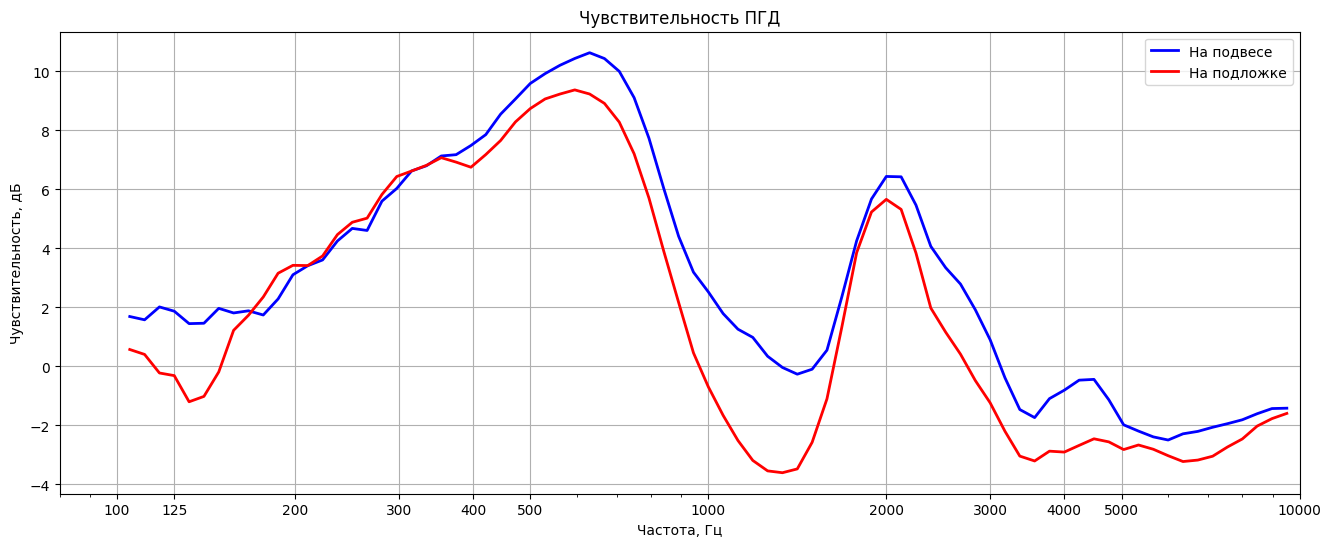

In [54]:
desired_ticks =[
    100, 125, 200, 300, 400, 500, 1000,
    2000, 3000, 4000, 5000, 10000
]
plt.figure(figsize=(16,6))
plt.plot(f0[window-1:], y_smooth_db_, 'r-', linewidth=2, color='blue', label = 'На подвесе')
plt.plot(f0[window-1:], y_smooth_db, 'r-', linewidth=2, color='red', label = 'На подложке')
plt.legend()
plt.xlabel("Частота, Гц")
plt.ylabel("Чувствительность, дБ")
plt.grid(True)
plt.xscale('log')
plt.xlim(80, 10001)
plt.title('Чувствительность ПГД')
plt.xticks(desired_ticks, [str(t) for t in desired_ticks])
plt.show()